# Decision Tree



Cây quyết định là một thuật toán học có giám sát phi tham số (nghĩa là nó không có cái bộ tham số $w,b$ như Linear và Logistic Regression), có những đặc điểm sau:


- Có cấu trúc cây phân cấp giống như sơ đồ gồm node gốc (Root Node), nhánh (Branch Node) và node lá (Leaf Node). Các node gốc, nhánh biểu diễn các quy tắc logic; node lá biểu diễn kết quả của dữ liệu.
- Biểu thị giống sự suy nghĩ của con người nên nó đơn giản dể hiểu.
- Áp dụng cho cả vấn đề phân lớp(Classification) cũng như hồi quy (Regression)
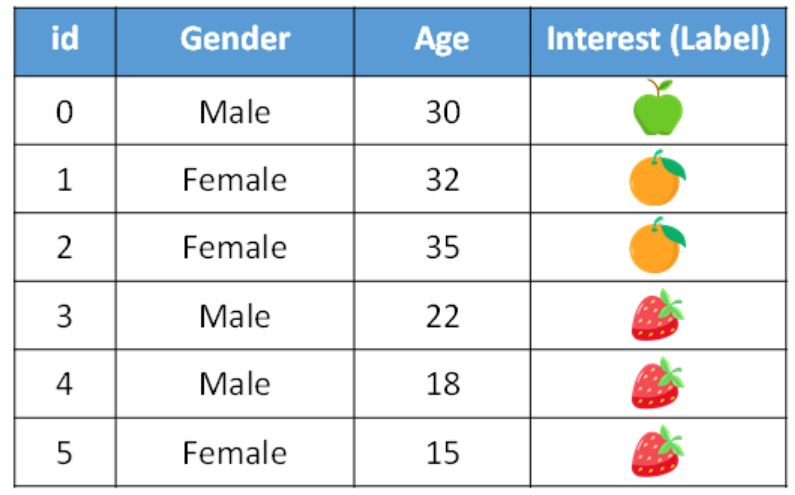

Độ không thuần khiết (Impurity) của dữ liệu


- Entropy
- Information Gain (IG)


Entropy


$$
\Large Entropy = \sum_{i=1}^{n} p_i.log_2 \biggl(\frac{1}{p_i} \biggr) = \sum_{i=1}^{n} -p_i.log_2 (p_i)
$$


Giá trị entropy càng lớn thì độ impurity càng cao



Information Gain (IG)
$$
\begin{align}
\Large IG_{entropy} &= \Large E(parent) - \sum_{i=1}^{n} w_{i}\times E(child_{i})
\end{align}
$$

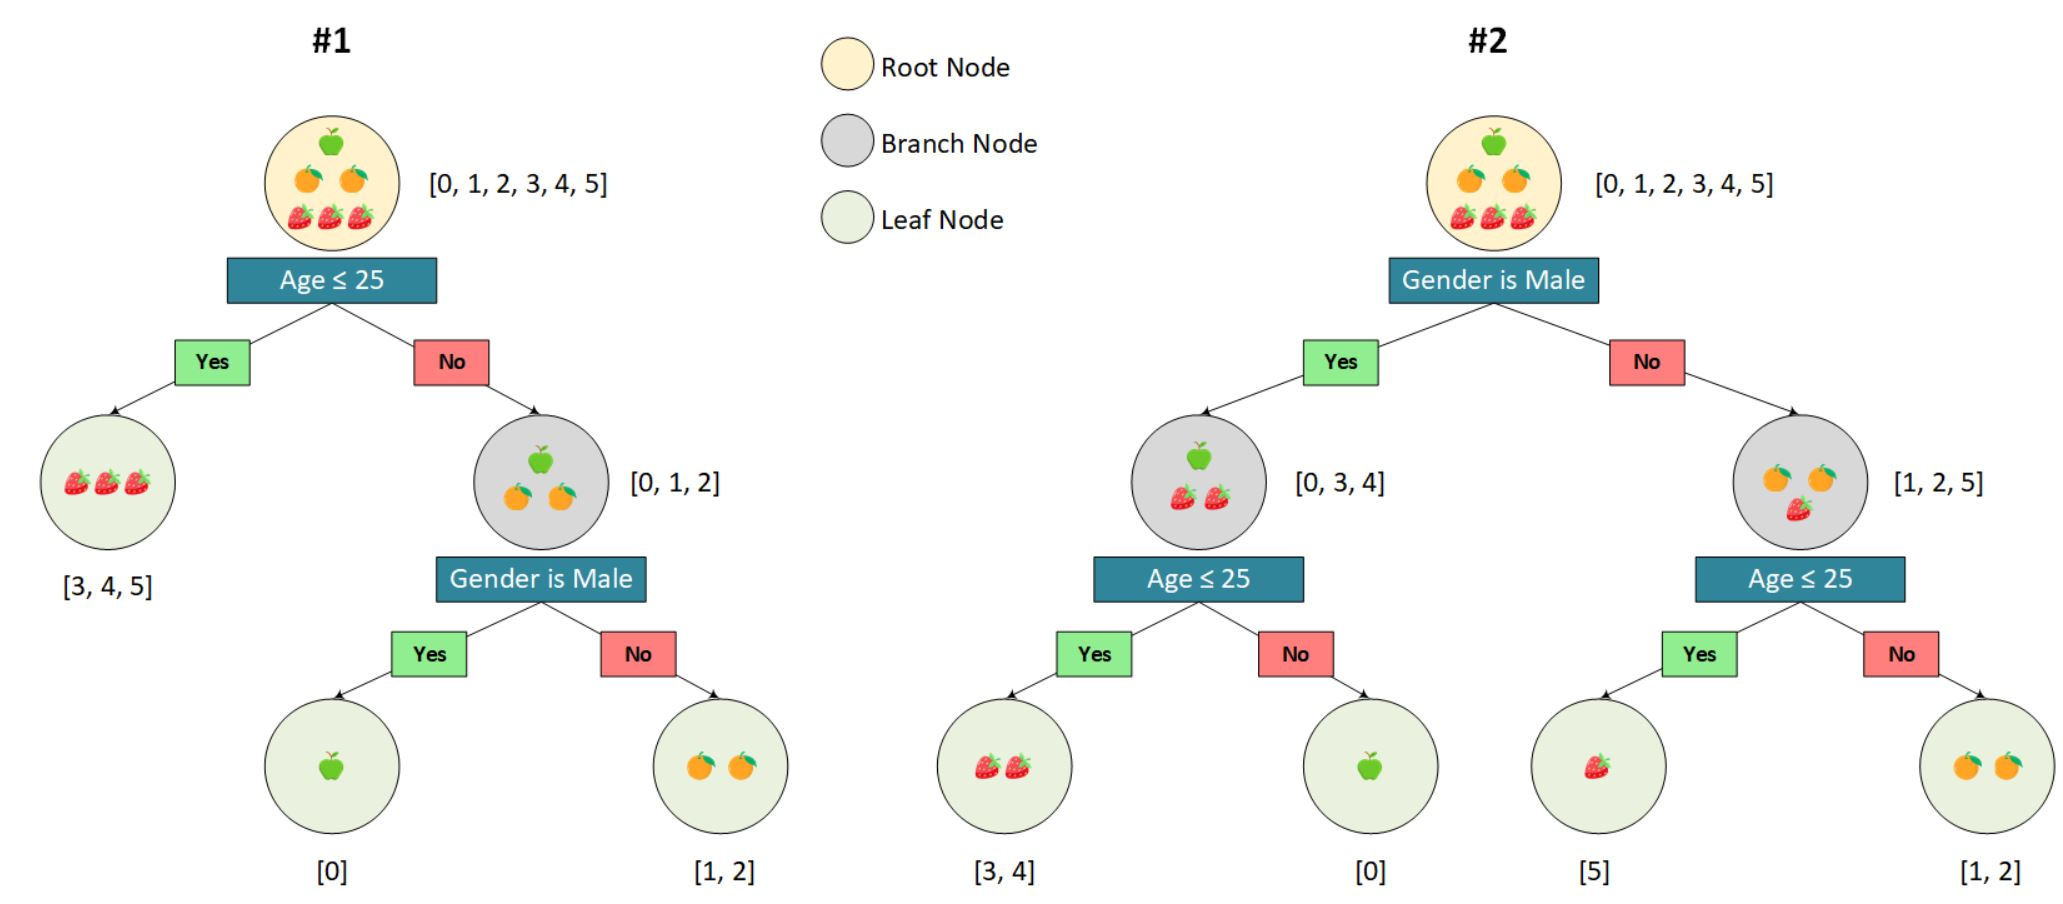

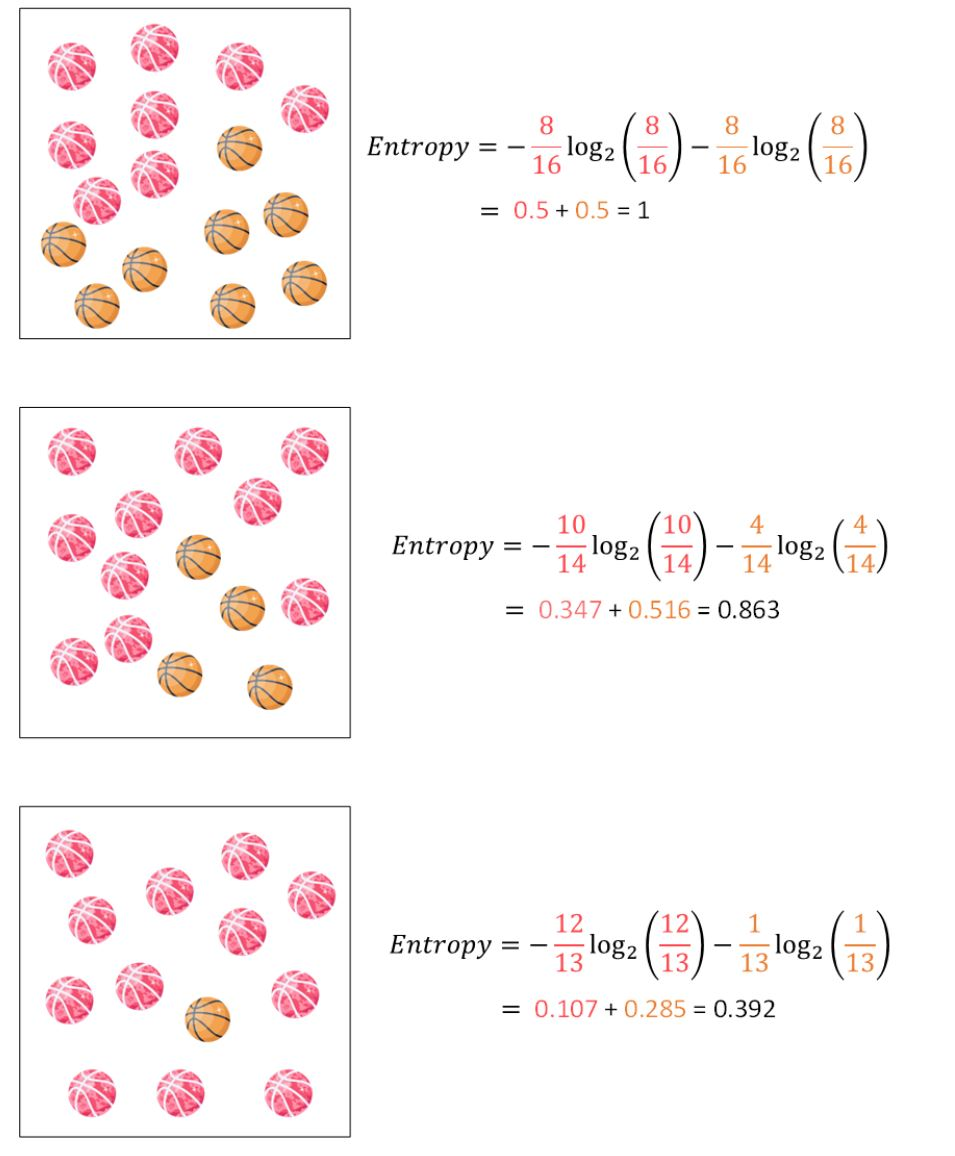

## 1. Nạp dữ liệu

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Nạp dữ liệu

In [39]:
dataset = pd.read_csv('/content/drive/MyDrive/2321004059_PhanHongPhuc_KPDL/Chuong4/Decision Tree/Data/Bản sao của Admittance.csv')
dataset.head(5)

,SAT,Admitted
0,1363,No
1,1792,Yes
2,1954,Yes
3,1653,No
4,1593,No


In [40]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   SAT       168 non-null    int64 
 1   Admitted  168 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [41]:
dataset.describe()

,SAT
count,168.000000
mean,1695.273810
std,183.019017
min,1334.000000
25%,1547.500000
50%,1691.500000
75%,1844.500000
max,2050.000000


In [42]:
#Tiền xử lý chuyển No->0, Yes->1
dataset['Admitted'] = dataset['Admitted'].map({'No':0,'Yes':1})
dataset.head(5)

,SAT,Admitted
0,1363,0
1,1792,1
2,1954,1
3,1653,0
4,1593,0


## 3. Truc quan hoa du lieu

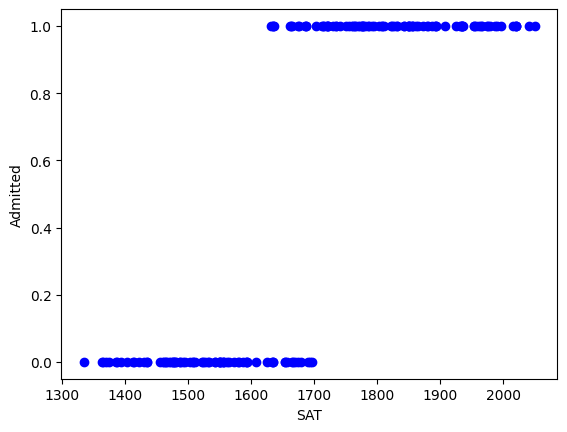

In [43]:
plt.scatter(dataset['SAT'],dataset['Admitted'],color='blue')
plt.xlabel('SAT')
plt.ylabel('Admitted')
plt.show()

## 4. Tách biến độc lập và biến phụ thuôc

In [44]:
X = dataset.iloc[:,:-1]
y = dataset.iloc[:,-1]

In [45]:
X.head(5)

,SAT
0,1363
1,1792
2,1954
3,1653
4,1593


In [46]:
y.head(5)

,Admitted
0,0
1,1
2,1
3,0
4,0


##5. Phân chia thành tập huấn luyện và tập kiểm thử

In [47]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

## 6. Huấn luyện mô hình Decision Tree

In [48]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion='entropy') #criterion = 'gini'
classifier.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy')

## 6. Trực quan hóa cây quyết định

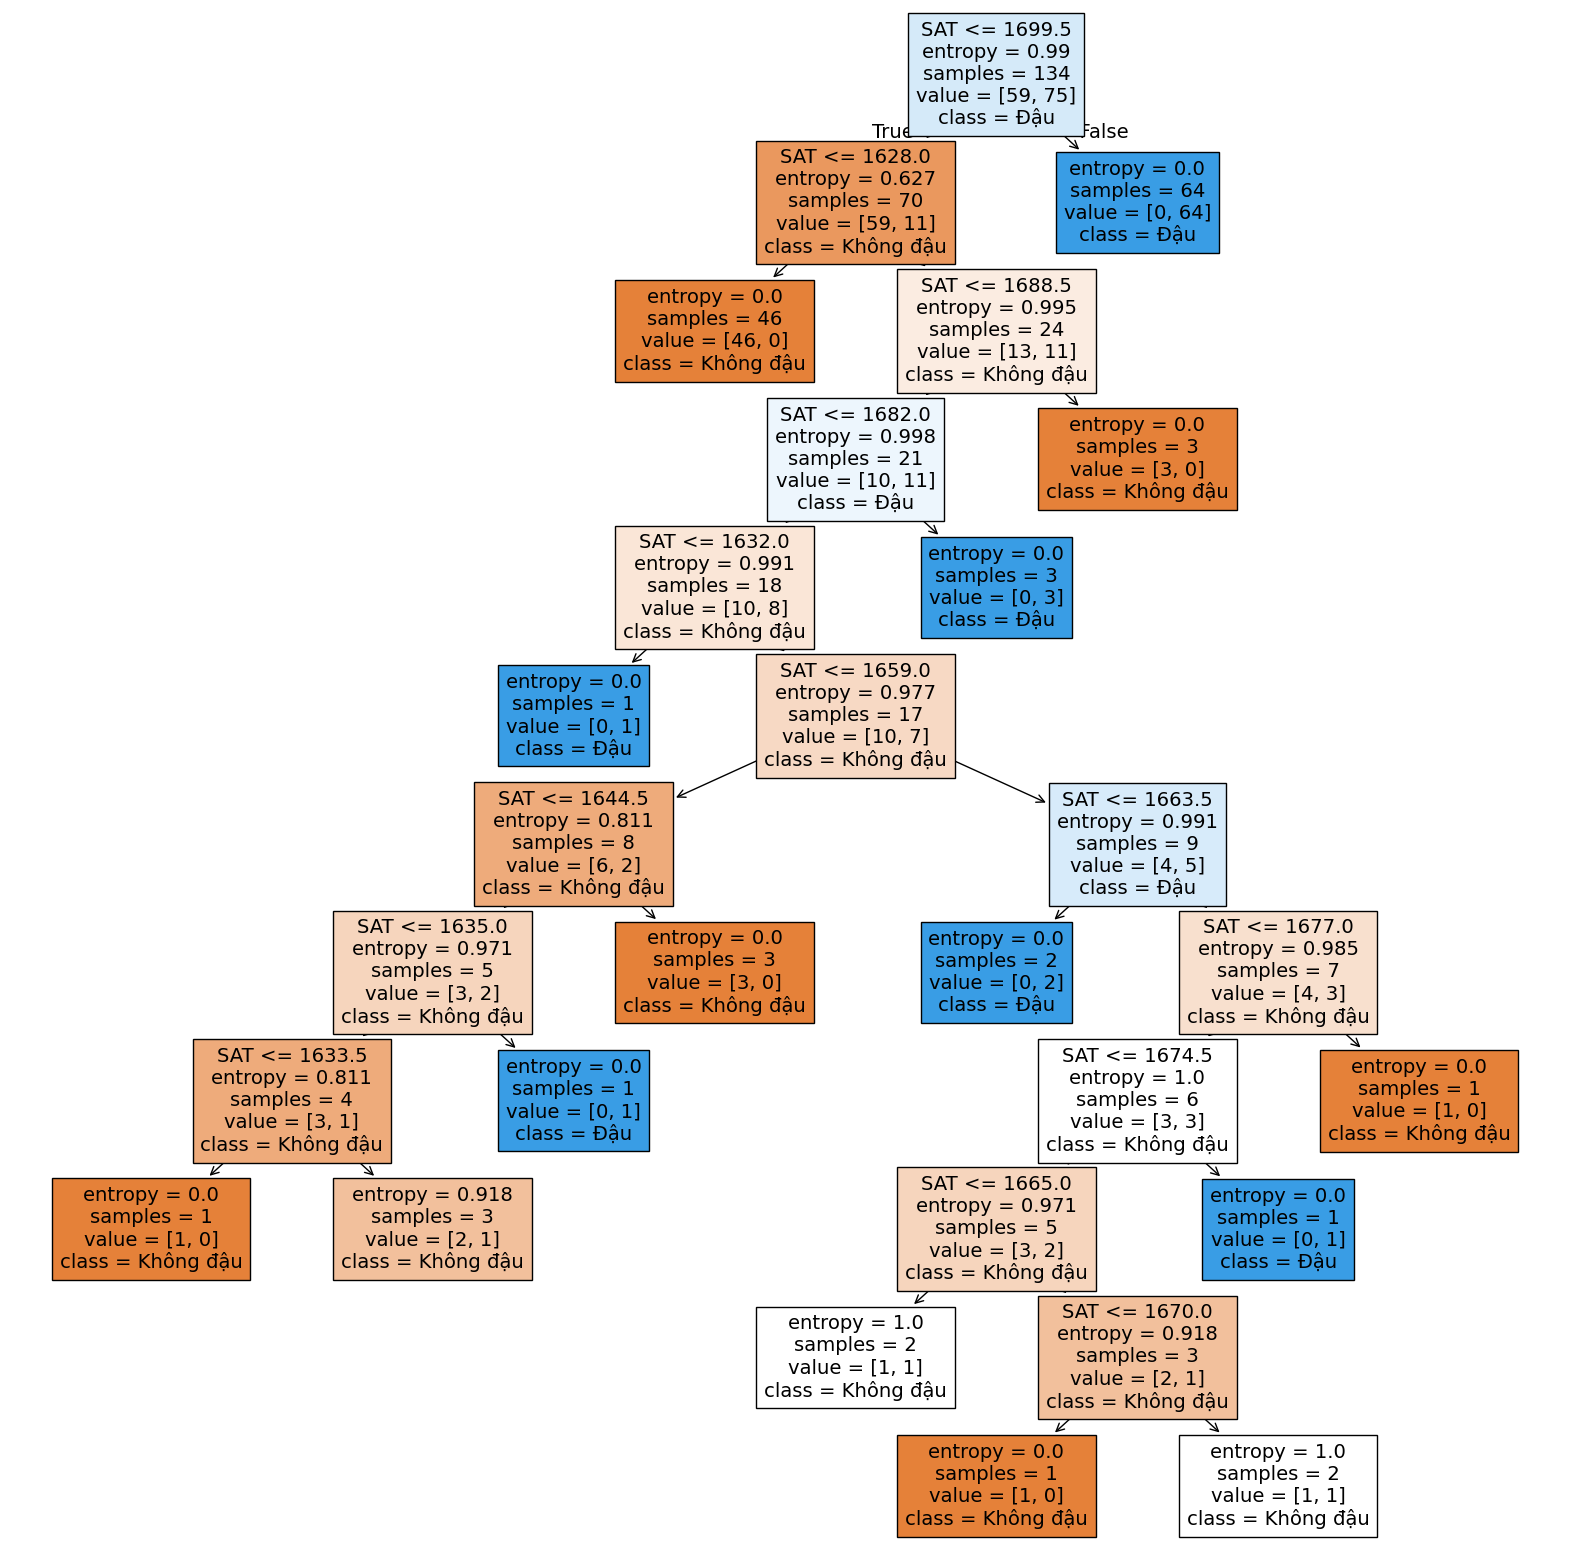

In [49]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,20))
plot_tree(classifier,filled=True,class_names=['Không đậu','Đậu'],feature_names=X.columns)
plt.show()

## 7. Đánh giá mô hình

In [50]:
y_pred = classifier.predict(X_test)


In [51]:
from sklearn.metrics import confusion_matrix,accuracy_score,recall_score,f1_score,precision_score
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[15  0]
 [ 1 18]]


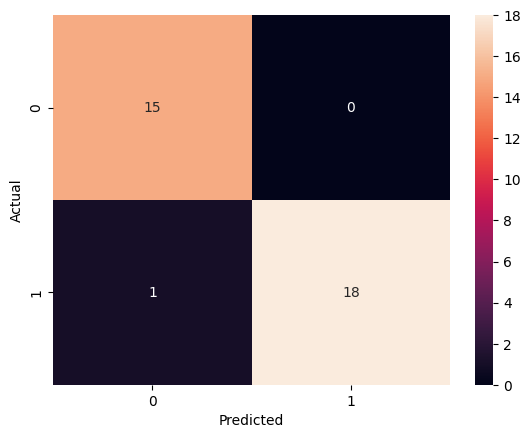

In [52]:
import seaborn as sns
sns.heatmap(cm,annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [53]:
print('Accuracy: ',accuracy_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('F1 score: ',f1_score(y_test,y_pred))


Accuracy:  0.9705882352941176
Recall:  0.9473684210526315
Precision:  1.0
F1 score:  0.972972972972973


## 8. Sử dụng gird search để tune tham số tốt nhất và áp dụng cross validation (kiểm định chéo)

In [54]:
para_grid = {
    'criterion':['gini','entropy'],
    'max_depth' : [None,2,3,5,10,20],
    'min_samples_split':[1,2,5,10],
    'min_samples_leaf':[2,5,10,15,100]
}

In [55]:
dt = DecisionTreeClassifier()#gọi ra nhưng k đưa tham số vào bên trong
#Sử dụng thư viện Grid Search để tune tham số và cross validation
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(estimator=dt,param_grid=para_grid,cv=5,scoring='accuracy')

grid_search.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
300 fits failed out of a total of 1200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
300 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/uti

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 2, 3, 5, 10, 20],
                         'min_samples_leaf': [2, 5, 10, 15, 100],
                         'min_samples_split': [1, 2, 5, 10]},
             scoring='accuracy')

In [56]:
#Hiển thị bộ tham số tốt nhất của mô hình
best_param = grid_search.best_params_
print(best_param)

{'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [57]:
#Sử dụng tham số tốt nhất để dự đoán y_pred
y_pred_tune = grid_search.best_estimator_.predict(X_test)

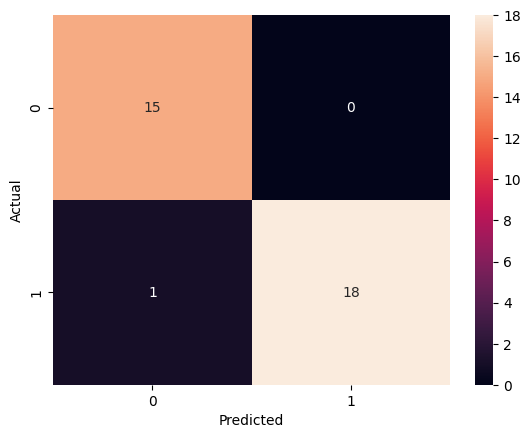

In [58]:
#Đánh giá mô hình dựa trên tham số tốt nhất tìm được thông qua GridSearch
cm_tune = confusion_matrix(y_test,y_pred_tune)
sns.heatmap(cm_tune,annot=True,fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [59]:
print('Accuracy: ',accuracy_score(y_test,y_pred_tune))
print('Recall: ',recall_score(y_test,y_pred_tune))
print('Precision: ',precision_score(y_test,y_pred_tune))
print('F1 score: ',f1_score(y_test,y_pred_tune))
#

Accuracy:  0.9705882352941176
Recall:  0.9473684210526315
Precision:  1.0
F1 score:  0.972972972972973
